In [1]:
import os
import joblib
from IPython.display import display, Latex

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from utils import *

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

datasets_dict = {
    'Chowell_train': 'Cho1',
    'Chowell_test': 'Cho2',
    'MSK1': 'MSK1',
    'MSK2': 'MSK2',
    'Shim_NSCLC': 'Shim',
    'Kato_panCancer': 'Kato',
    'Vanguri_NSCLC': 'Vang',
    'Ravi_NSCLC': 'Ravi',
    'Pradat_panCancer': 'Prad'
}

n_datasets = len(datasets_ids)

# Accuracies

## Comparison accuracies on Chowell_train

In [3]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

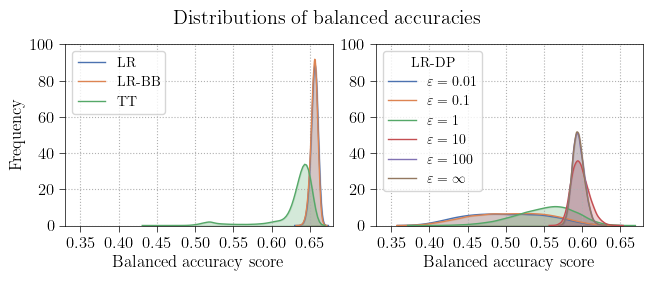

In [4]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

palette = sns.color_palette('deep')
colors = palette#[0], palette[1], palette[2], palette
# colors = plt.cm.tab10.colors

model_names_dict = {
    'lr': 'LR',
    'lr_priv': 'LR-BB',
    'tt': 'TT'
}

fig, ax = plt.subplots(1, 2, figsize=(6.5, 2.75))


# lr, lr-priv, tt
for i, model_name in enumerate(['lr', 'lr_priv', 'tt']):
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    mask = data['labels'][:, 0] == 1
    accs = data['bal_accs'][mask]
    
    data_plot = accs[:, -1].numpy()
    
    kde = gaussian_kde(data_plot)  # fits a smooth PDF
    x = np.linspace(data_plot.min(), data_plot.max(), 100)
    y = kde(x)
    
    ax[0].plot(x, y,
               linewidth=1.,
               color=colors[i],
               label=model_names_dict[model_name])
    ax[0].fill_between(x, y,
                       alpha=0.25,
                       color=colors[i])  # shadow below curve

ax[0].set_xlabel('Balanced accuracy score')
ax[0].set_ylabel('Frequency')
ax[0].set_ylim(0, 100)
ax[0].set_xlim(0.33, 0.68)
ax[0].set_xticks(torch.arange(0.35, 0.70, 0.05))
ax[0].grid(True, zorder=-1, linestyle=':')

ax[0].legend()


# lr_dp
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}
for i, epsilon in enumerate(epsilon_list):
    data_dir = os.path.join(cwd, 'results', 'datasets', 'lr_dp',
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    mask = data['labels'][:, 0] == 1
    accs = data['bal_accs'][mask]
    
    data_plot = accs[:, 0].numpy()
    
    kde = gaussian_kde(data_plot)  # fits a smooth PDF
    x = np.linspace(data_plot.min(), data_plot.max(), 100)
    y = kde(x)
    
    ax[1].plot(x, y,
               linewidth=1.,
               color=colors[i],
               label=fr'$\varepsilon={epsilon_dict[epsilon]}$')
    ax[1].fill_between(x, y,
                       alpha=0.25,
                       color=colors[i])  # shadow below curve

ax[1].set_xlabel('Balanced accuracy score')
ax[1].set_ylim(0, 100)
ax[1].set_xlim(0.33, 0.68)
ax[1].set_xticks(torch.arange(0.35, 0.70, 0.05))
ax[1].grid(True, zorder=-1, linestyle=':')

ax[1].legend(title='LR-DP')

fig.suptitle('Distributions of balanced accuracies')

# Show plot
plt.tight_layout(pad=0.5)
plt.savefig(os.path.join(figures_dir, 'accuracies_chowell_train.pdf'),
            bbox_inches='tight')
plt.show()

## Models trained on each dataset

In [5]:
scaler_type = 'standard'

for model_name in ['lr', 'lr_priv', 'tt']:
    for model_type in ['vanilla', 'average']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for train_did in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[train_did] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()

            accs = data['bal_accs'][mask, train_did]
            aucs = data['auc_scores'][mask, train_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

LR | VANILLA | 0.67, 0.74 | 0.69, 0.77 | 0.68, 0.72 | 0.60, 0.63 | 0.62, 0.65 | 0.72, 0.77 | 0.62, 0.67 | 0.67, 0.74 | 0.70, 0.79 | 
LR | AVERAGE | 0.67, 0.74 | 0.69, 0.78 | 0.68, 0.72 | 0.65, 0.64 | 0.64, 0.65 | 0.62, 0.85 | 0.62, 0.67 | 0.68, 0.74 | 0.72, 0.78 | 
LR_PRIV | VANILLA | 0.67, 0.74 | 0.69, 0.77 | 0.68, 0.71 | 0.59, 0.63 | 0.61, 0.65 | 0.68, 0.74 | 0.61, 0.67 | 0.67, 0.74 | 0.70, 0.76 | 
LR_PRIV | AVERAGE | 0.67, 0.74 | 0.69, 0.77 | 0.68, 0.72 | 0.63, 0.64 | 0.63, 0.65 | 0.62, 0.81 | 0.61, 0.68 | 0.66, 0.74 | 0.74, 0.78 | 
TT | VANILLA | 0.65, 0.72 | 0.68, 0.75 | 0.65, 0.69 | 0.58, 0.62 | 0.61, 0.64 | 0.70, 0.76 | 0.61, 0.67 | 0.67, 0.74 | 0.70, 0.77 | 
TT | AVERAGE | 0.66, 0.72 | 0.68, 0.76 | 0.65, 0.70 | 0.59, 0.64 | 0.62, 0.65 | 0.62, 0.83 | 0.61, 0.67 | 0.67, 0.74 | 0.74, 0.80 | 


## Models trained on datasets that contains each dataset

In [6]:
scaler_type = 'standard'

for model_name in ['lr', 'lr_priv', 'tt']:
    for model_type in ['vanilla', 'average']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for train_did in range(n_datasets):
            mask = data['labels'][:, train_did] == 1

            accs = data['bal_accs'][mask, train_did]
            aucs = data['auc_scores'][mask, train_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

LR | VANILLA | 0.68, 0.74 | 0.69, 0.76 | 0.67, 0.70 | 0.59, 0.62 | 0.58, 0.61 | 0.57, 0.74 | 0.64, 0.66 | 0.65, 0.73 | 0.61, 0.69 | 
LR | AVERAGE | 0.68, 0.74 | 0.70, 0.76 | 0.68, 0.71 | 0.59, 0.63 | 0.58, 0.61 | 0.55, 0.74 | 0.64, 0.67 | 0.65, 0.73 | 0.61, 0.69 | 
LR_PRIV | VANILLA | 0.68, 0.74 | 0.69, 0.76 | 0.67, 0.70 | 0.59, 0.62 | 0.58, 0.61 | 0.57, 0.73 | 0.64, 0.66 | 0.65, 0.73 | 0.61, 0.69 | 
LR_PRIV | AVERAGE | 0.68, 0.74 | 0.70, 0.76 | 0.67, 0.71 | 0.59, 0.63 | 0.58, 0.61 | 0.57, 0.73 | 0.64, 0.67 | 0.65, 0.73 | 0.61, 0.69 | 
TT | VANILLA | 0.65, 0.71 | 0.67, 0.72 | 0.65, 0.69 | 0.57, 0.62 | 0.59, 0.61 | 0.52, 0.63 | 0.63, 0.66 | 0.65, 0.73 | 0.58, 0.65 | 
TT | AVERAGE | 0.65, 0.71 | 0.67, 0.72 | 0.66, 0.69 | 0.57, 0.62 | 0.59, 0.61 | 0.50, 0.63 | 0.63, 0.66 | 0.65, 0.73 | 0.58, 0.65 | 


## Heatmaps

In [7]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

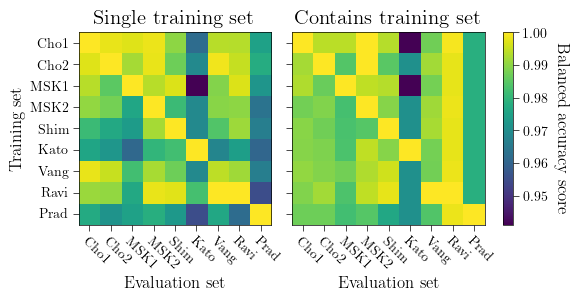

In [8]:
scaler_type = 'standard'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'lr',
    scaler_type, 'vanilla', 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

n_datasets = len(datasets_ids)

# Only use dataset to train
matrix1 = []
for train_did in range(n_datasets):
    eval_list = []
    for test_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        eval_list.append(accs.median().item())
    matrix1.append(eval_list)

matrix1 = torch.tensor(matrix1)
matrix1 = matrix1 / matrix1.max(dim=0, keepdim=True).values

# Train on bigger dataset that contains a dataset
matrix2 = []
for train_did in range(n_datasets):
    eval_list = []
    for test_did in range(n_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        eval_list.append(accs.median().item())
    matrix2.append(eval_list)

matrix2 = torch.tensor(matrix2)
matrix2 = matrix2 / matrix2.max(dim=0, keepdim=True).values

# Find global min and max across both matrices
vmin = min(matrix1.min().item(), matrix2.min().item())
vmax = max(matrix1.max().item(), matrix2.max().item())

# fig, ax = plt.subplots(1, 2, figsize=(8, 3.25))
fig, ax = plt.subplots(
    1, 2, figsize=(6, 2.5),
    gridspec_kw={'wspace': 0.01}  # small gap between heatmaps
)

x_labels = [datasets_dict[datasets[i]]
            for i in range(n_datasets)]
y_labels = [datasets_dict[datasets[i]]
            for i in range(n_datasets)]

# Plot the matrix1
im1 = ax[0].imshow(matrix1, cmap='viridis')

ax[0].set_xticks(range(n_datasets))
ax[0].set_yticks(range(n_datasets))
ax[0].set_xticklabels(x_labels, rotation=-45,
                      ha='left', rotation_mode='anchor')
ax[0].set_yticklabels(y_labels)
ax[0].set_xlabel('Evaluation set')
ax[0].set_ylabel('Training set')
ax[0].set_title('Single training set')

# Plot the matrix2
im2 = ax[1].imshow(matrix2, cmap='viridis')

ax[1].set_xticks(range(n_datasets))
ax[1].set_yticks(range(n_datasets))
ax[1].set_xticklabels(x_labels, rotation=-45,
                      ha='left', rotation_mode='anchor')
ax[1].set_yticklabels([''] * n_datasets)
ax[1].set_xlabel('Evaluation set')
ax[1].set_title('Contains training set')

# Add colorbar
cbar = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Balanced accuracy score', rotation=270, labelpad=15)

# Show plot
plt.savefig(os.path.join(figures_dir, 'accuracies_heatmap.pdf'),
            bbox_inches='tight')
plt.show()

## Models trained on Chowell_train

In [9]:
scaler_type = 'standard'

for model_name in ['lr', 'lr_priv', 'tt']:
    for model_type in ['vanilla', 'average']:
        print(f'{model_name.upper()} | {model_type.upper()}', end=' | ')
        data_dir = os.path.join(
            cwd, 'results', 'datasets', model_name,
            scaler_type, model_type, 'params_multilabel.pt'
        )
        data = torch.load(data_dir, weights_only=True)

        n_datasets = len(datasets_ids)
        for test_did in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[0] = 1
            mask = (data['labels'] == cond_vector).all(dim=1).bool()
            
            accs = data['bal_accs'][mask, test_did]
            aucs = data['auc_scores'][mask, test_did]
            
            print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
        print()

LR | VANILLA | 0.67, 0.74 | 0.68, 0.75 | 0.66, 0.70 | 0.59, 0.63 | 0.58, 0.60 | 0.53, 0.75 | 0.61, 0.66 | 0.64, 0.73 | 0.58, 0.72 | 
LR | AVERAGE | 0.67, 0.74 | 0.68, 0.75 | 0.67, 0.70 | 0.59, 0.63 | 0.57, 0.60 | 0.43, 0.71 | 0.61, 0.66 | 0.64, 0.73 | 0.59, 0.72 | 
LR_PRIV | VANILLA | 0.67, 0.74 | 0.69, 0.75 | 0.66, 0.69 | 0.59, 0.63 | 0.58, 0.59 | 0.58, 0.77 | 0.62, 0.66 | 0.64, 0.72 | 0.58, 0.71 | 
LR_PRIV | AVERAGE | 0.67, 0.74 | 0.69, 0.75 | 0.67, 0.70 | 0.59, 0.63 | 0.57, 0.59 | 0.53, 0.79 | 0.61, 0.66 | 0.64, 0.73 | 0.58, 0.72 | 
TT | VANILLA | 0.65, 0.72 | 0.66, 0.72 | 0.66, 0.69 | 0.59, 0.63 | 0.58, 0.60 | 0.52, 0.65 | 0.61, 0.66 | 0.64, 0.72 | 0.57, 0.68 | 
TT | AVERAGE | 0.66, 0.72 | 0.66, 0.72 | 0.66, 0.69 | 0.59, 0.63 | 0.58, 0.60 | 0.47, 0.63 | 0.61, 0.66 | 0.64, 0.73 | 0.57, 0.68 | 


In [10]:
scaler_type = 'standard'
model_name = 'lr_dp'

for epsilon in epsilon_list:
    print(f'{model_name.upper()} ({epsilon:<6.1f}) | {model_type.upper()}', end=' | ')
    data_dir = os.path.join(
        cwd, 'results', 'datasets', model_name,
        scaler_type, 'vanilla', f'params_multilabel_{epsilon}.pt'
    )
    data = torch.load(data_dir, weights_only=True)

    n_datasets = len(datasets_ids)
    for test_did in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()
        
        accs = data['bal_accs'][mask, test_did]
        aucs = data['auc_scores'][mask, test_did]
        
        print(f'{accs.median().item():.2f}, {aucs.median().item():.2f}', end=' | ')
    print()

LR_DP (0.0   ) | AVERAGE | 0.51, 0.51 | 0.52, 0.52 | 0.50, 0.51 | 0.51, 0.51 | 0.51, 0.50 | 0.48, 0.48 | 0.50, 0.51 | 0.50, 0.50 | 0.53, 0.52 | 
LR_DP (0.1   ) | AVERAGE | 0.51, 0.52 | 0.51, 0.52 | 0.50, 0.51 | 0.50, 0.50 | 0.50, 0.49 | 0.50, 0.48 | 0.50, 0.52 | 0.50, 0.49 | 0.51, 0.50 | 
LR_DP (1.0   ) | AVERAGE | 0.55, 0.57 | 0.55, 0.57 | 0.52, 0.53 | 0.50, 0.52 | 0.51, 0.54 | 0.52, 0.52 | 0.54, 0.57 | 0.55, 0.59 | 0.53, 0.54 | 
LR_DP (10.0  ) | AVERAGE | 0.61, 0.72 | 0.62, 0.73 | 0.57, 0.68 | 0.50, 0.62 | 0.53, 0.60 | 0.50, 0.67 | 0.54, 0.66 | 0.57, 0.72 | 0.50, 0.68 | 
LR_DP (100.0 ) | AVERAGE | 0.61, 0.74 | 0.63, 0.75 | 0.58, 0.69 | 0.54, 0.63 | 0.53, 0.60 | 0.48, 0.75 | 0.55, 0.66 | 0.57, 0.73 | 0.49, 0.72 | 
LR_DP (inf   ) | AVERAGE | 0.61, 0.74 | 0.63, 0.75 | 0.58, 0.70 | 0.54, 0.63 | 0.53, 0.60 | 0.48, 0.75 | 0.54, 0.66 | 0.57, 0.73 | 0.49, 0.72 | 


# Attacks

## Models trained on each dataset

### Weak Black-Box

In [11]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9187, std = 0.0170
Ham. Acc. lr_priv: mean = 0.9127, std = 0.0112
Ham. Acc. tt: mean = 0.8431, std = 0.0091

average:
Ham. Acc. lr: mean = 0.9606, std = 0.0173
Ham. Acc. lr_priv: mean = 0.9438, std = 0.0086
Ham. Acc. tt: mean = 0.8721, std = 0.0142



In [12]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', 'tt',
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', 'tt',
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    mask = torch.logical_and(mask, data['bal_accs'][:, -1] >= 0.60)
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. tt (high bal. acc.): mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. tt (high bal. acc.): mean = 0.8153, std = 0.0089

average:
Ham. Acc. tt (high bal. acc.): mean = 0.8635, std = 0.0109



In [13]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.01): mean = 0.6117, std = 0.0241
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.6212, std = 0.0261
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.6580, std = 0.0308
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7305, std = 0.0231
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8127, std = 0.0220
Ham. Acc. lr_dp ($\varepsilon=$\infty): mean = 0.8304, std = 0.0249



### Strong Black-Box

In [14]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8990, std = 0.0419
Ham. Acc. lr_priv: mean = 0.9343, std = 0.0142
Ham. Acc. tt: mean = 0.8657, std = 0.0283

average:
Ham. Acc. lr: mean = 0.9272, std = 0.0593
Ham. Acc. lr_priv: mean = 0.9722, std = 0.0223
Ham. Acc. tt: mean = 0.8868, std = 0.0362



In [15]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.01): mean = 0.6120, std = 0.0265
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.6230, std = 0.0220
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.6689, std = 0.0252
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7795, std = 0.0187
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8823, std = 0.0362
Ham. Acc. lr_dp ($\varepsilon=$\infty): mean = 0.8758, std = 0.0450



### White-Box

In [16]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        if model_name == 'tt':
            X, y = data['cores'], data['labels']
        else:
            X, y = data['params'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(n_datasets):
            cond_vector = torch.zeros(n_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                  f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            all_preds = np.array([model.predict_proba(X_test)
                                  for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9096, std = 0.0079
Ham. Acc. lr_priv: mean = 0.9385, std = 0.0047
Ham. Acc. tt: mean = 0.5540, std = 0.1217

average:
Ham. Acc. lr: mean = 0.9923, std = 0.0075
Ham. Acc. lr_priv: mean = 0.9719, std = 0.0110
Ham. Acc. tt: mean = 0.6083, std = 0.0915



In [17]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr_tt',
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', 'tt',
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['lr_params'], data['labels']
    
    # Avoid NaNs and infs in lr_tt params
    mask = ~X.isnan().any(dim=1)
    mask = mask * ~X.isinf().any(dim=1)
    
    aux_mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        aux_mask = torch.logical_or(aux_mask,
                                    (data['labels'] == cond_vector).all(dim=1))
    mask = mask * aux_mask
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. lr_tt: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_tt: mean = 0.7848, std = 0.0154
average:
Ham. Acc. lr_tt: mean = 0.7889, std = 0.0306



In [18]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['params'], data['labels']
    
    mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(n_datasets):
        cond_vector = torch.zeros(n_datasets)
        cond_vector[i] = 1
        mask = torch.logical_or(mask,
                                (data['labels'] == cond_vector).all(dim=1))
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{epsilon}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.01): mean = 0.4337, std = 0.1577
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.4111, std = 0.1960
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.4446, std = 0.1910
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.6662, std = 0.0371
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8196, std = 0.0246
Ham. Acc. lr_dp ($\varepsilon=$\infty): mean = 0.8937, std = 0.0155



## Models trained on datasets that contains each dataset

### Weak Black-Box

In [19]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.7927, std = 0.0062
Ham. Acc. lr_priv: mean = 0.7782, std = 0.0077
Ham. Acc. tt: mean = 0.7166, std = 0.0038

average:
Ham. Acc. lr: mean = 0.8730, std = 0.0113
Ham. Acc. lr_priv: mean = 0.8502, std = 0.0046
Ham. Acc. tt: mean = 0.7404, std = 0.0028



In [20]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.01): mean = 0.5412, std = 0.0032
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5408, std = 0.0028
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5792, std = 0.0029
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7055, std = 0.0039
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.7610, std = 0.0071
Ham. Acc. lr_dp ($\varepsilon=$\infty): mean = 0.7576, std = 0.0072



### Strong Black-Box

In [21]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8798, std = 0.0217
Ham. Acc. lr_priv: mean = 0.8628, std = 0.0081
Ham. Acc. tt: mean = 0.8180, std = 0.0137

average:
Ham. Acc. lr: mean = 0.9502, std = 0.0407
Ham. Acc. lr_priv: mean = 0.9377, std = 0.0130
Ham. Acc. tt: mean = 0.8650, std = 0.0134



In [22]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{epsilon}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.01): mean = 0.5428, std = 0.0043
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5414, std = 0.0039
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5871, std = 0.0036
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.7740, std = 0.0058
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8660, std = 0.0219
Ham. Acc. lr_dp ($\varepsilon=$\infty): mean = 0.8739, std = 0.0240



### White-Box

In [23]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        if model_name == 'tt':
            X, y = data['cores'], data['labels']
        else:
            X, y = data['params'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                  f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            all_preds = np.array([model.predict_proba(X_test)
                                  for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8995, std = 0.0015
Ham. Acc. lr_priv: mean = 0.8913, std = 0.0014
Ham. Acc. tt: mean = 0.5590, std = 0.0273

average:
Ham. Acc. lr: mean = 0.9974, std = 0.0032
Ham. Acc. lr_priv: mean = 0.9777, std = 0.0050
Ham. Acc. tt: mean = 0.5770, std = 0.0176



In [24]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr_tt',
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', 'tt',
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['lr_params'], data['labels']
    
    # Avoid NaNs and infs in lr_tt params
    mask = ~X.isnan().any(dim=1)
    mask = mask * ~X.isinf().any(dim=1)
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. lr_tt: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_tt: mean = 0.7398, std = 0.0016
average:
Ham. Acc. lr_tt: mean = 0.7803, std = 0.0022



In [25]:
scaler_type = 'standard'
model_type = 'vanilla'
model_name = 'lr_dp'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
epsilon_dict = {
    0.01  : '0.01',
    0.1   : '0.1',
    1.0   : '1',
    10.0  : '10',
    100.0 : '100',
    float('inf') : r'\infty'}

print(f'{model_type}:')
for epsilon in epsilon_list:
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type,
                            f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['params'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{epsilon}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(fr'Ham. Acc. {model_name} ($\varepsilon=${epsilon_dict[epsilon]}): '
          fr'mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_dp ($\varepsilon=$0.01): mean = 0.5258, std = 0.0343
Ham. Acc. lr_dp ($\varepsilon=$0.1): mean = 0.5307, std = 0.0365
Ham. Acc. lr_dp ($\varepsilon=$1): mean = 0.5359, std = 0.0359
Ham. Acc. lr_dp ($\varepsilon=$10): mean = 0.6379, std = 0.0141
Ham. Acc. lr_dp ($\varepsilon=$100): mean = 0.8636, std = 0.0083
Ham. Acc. lr_dp ($\varepsilon=$\infty): mean = 0.8977, std = 0.0030



## Attack accuracies by dataset

### Weak Black-Box

In [26]:
attack_name = 'weak'
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr', 'tt']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['bin_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9238, 0.8942, 0.8971, 0.7086, 0.7374, 0.5822, 0.7140, 0.8492, 0.8274])
std =  tensor([0.0019, 0.0012, 0.0015, 0.0214, 0.0082, 0.0163, 0.0127, 0.0021, 0.0034])

vanilla - tt:
Ham. Acc. tt:
mean =  tensor([0.8546, 0.8093, 0.8135, 0.6384, 0.6671, 0.5490, 0.6408, 0.7526, 0.7240])
std =  tensor([0.0017, 0.0011, 0.0026, 0.0202, 0.0024, 0.0064, 0.0115, 0.0018, 0.0015])



### Strong Black-Box

In [27]:
attack_name = 'strong'
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr', 'tt']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['out_scores'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        mlp_bb = joblib.load(
            os.path.join(attacker_dir,
                        f'mlp_bb_{attack_name}_{i+1}.pkl'))
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        y_pred = mlp_bb.predict(X_test)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9936, 0.9742, 0.9588, 0.9742, 0.8324, 0.5959, 0.7128, 0.9360, 0.9405])
std =  tensor([0.0019, 0.0018, 0.0403, 0.0031, 0.0936, 0.0428, 0.0786, 0.0175, 0.0061])

vanilla - tt:
Ham. Acc. tt:
mean =  tensor([0.9628, 0.9072, 0.9028, 0.9500, 0.7277, 0.5566, 0.6646, 0.8545, 0.8363])
std =  tensor([0.0025, 0.0059, 0.0084, 0.0023, 0.0531, 0.0170, 0.0575, 0.0036, 0.0353])



### White-Box

In [28]:
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr', 'tt']:
    print(f'{model_type} - {model_name}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    if model_name == 'tt':
        X, y = data['cores'], data['labels']
    else:
        X, y = data['params'], data['labels']
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                                n_repeats=n_repeats,
                                random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        X_test, y_test = X[test_idx], y[test_idx]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        values_by_dataset = []
        for did in range(n_datasets):
            val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
            values_by_dataset.append(val)
        values.append(values_by_dataset)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. {model_name}:')
    print('mean = ', values.mean(dim=0))
    print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9982, 0.9911, 0.9728, 0.9815, 0.8630, 0.7672, 0.6331, 0.9420, 0.9468])
std =  tensor([0.0002, 0.0003, 0.0009, 0.0006, 0.0013, 0.0040, 0.0140, 0.0012, 0.0008])

vanilla - tt:
Ham. Acc. tt:
mean =  tensor([0.6514, 0.6623, 0.5618, 0.5391, 0.5118, 0.5183, 0.5162, 0.5213, 0.5485])
std =  tensor([0.0710, 0.0811, 0.0289, 0.0384, 0.0067, 0.0129, 0.0089, 0.0114, 0.0209])



## Attack accuracies Chowell_train vs Chowell_train + Kato

### Weak Black-Box

In [29]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    for model_name in ['lr', 'tt']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                                f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9936, 0.5383])
std =  tensor([0.0048, 0.0237])
vanilla - tt:
Ham. Acc. tt:
mean =  tensor([0.9707, 0.5189])
std =  tensor([0.0074, 0.0279])

average - lr:
Ham. Acc. lr:
mean =  tensor([1.0000, 0.5278])
std =  tensor([0.0000, 0.0362])
average - tt:
Ham. Acc. tt:
mean =  tensor([0.9794, 0.5282])
std =  tensor([0.0058, 0.0334])



### Strong Black-Box

In [30]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    for model_name in ['lr', 'tt']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9975, 0.5410])
std =  tensor([0.0039, 0.0449])
vanilla - tt:
Ham. Acc. tt:
mean =  tensor([0.9971, 0.5261])
std =  tensor([0.0026, 0.0243])

average - lr:
Ham. Acc. lr:
mean =  tensor([0.9974, 0.7464])
std =  tensor([0.0126, 0.2312])
average - tt:
Ham. Acc. tt:
mean =  tensor([0.9978, 0.5658])
std =  tensor([0.0023, 0.0751])



### White-Box

In [31]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    for model_name in ['lr', 'tt']:
        print(f'{model_type} - {model_name}:')
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        if model_name == 'tt':
            X, y = data['cores'], data['labels']
        else:
            X, y = data['params'], data['labels']
        
        cond_vector = torch.zeros(n_datasets)
        cond_vector[0] = 1
        mask1 = (data['labels'] == cond_vector).all(dim=1)
        
        cond_vector[5] = 1
        mask2 = (data['labels'] == cond_vector).all(dim=1)
        
        mask = torch.logical_or(mask1, mask2)
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                    n_repeats=n_repeats,
                                    random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                    f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            all_preds = np.array([model.predict_proba(X_test)
                                    for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            values_by_dataset = []
            for did in [0, 5]:
                val = 1 - hamming_loss(y_test[:, did], y_pred[:, did])
                values_by_dataset.append(val)
            values.append(values_by_dataset)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}:')
        print('mean = ', values.mean(dim=0))
        print('std = ', values.std(dim=0))
    print()

vanilla - lr:
Ham. Acc. lr:
mean =  tensor([0.9999, 0.7289])
std =  tensor([0.0006, 0.0279])
vanilla - tt:
Ham. Acc. tt:
mean =  tensor([0.7694, 0.4931])
std =  tensor([0.2441, 0.0237])

average - lr:
Ham. Acc. lr:
mean =  tensor([1.0000, 0.9989])
std =  tensor([0.0000, 0.0022])
average - tt:
Ham. Acc. tt:
mean =  tensor([0.9309, 0.4961])
std =  tensor([0.0488, 0.0226])



# Attack public LORIS models

## Attack LORIS from paper

In [32]:
model_type = 'average'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr',
                            'standard', model_type)
data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        'standard', model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['params'], data['labels']

# Load models
n_splits = 5
attack_models = []

# Load each model
for i in range(25):
    for j in range(n_splits):
        mlp_wb = joblib.load(os.path.join(attacker_dir,
                                            f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
        attack_models.append(mlp_wb)

In [33]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [35]:
classify_by_dataset(attack_models, X_loris, datasets)

   Chowell_train: 0.9987
    Chowell_test: 0.0313
            MSK1: 0.0024
            MSK2: 0.0398
      Shim_NSCLC: 0.0180
  Kato_panCancer: 0.0093
   Vanguri_NSCLC: 0.2048
      Ravi_NSCLC: 0.0240
Pradat_panCancer: 0.0169


## Attack online model: https://loris.ccr.cancer.gov/

In [36]:
datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

featuresNA = ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'
numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

scaler_type = 'standard'

data_train = load_data(os.path.join(cwd, '..'),
                       featuresNA,
                       phenoNA,
                       datasets,
                       datasets_ids)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

### Collect data and responses from online model

In [37]:
# TMB, PSTH, Albumin, NLR, Age, CTCT

# CTCT = Bladder, Breast, Colorectal, Endometrial, Esophageal, Gastric
#        Head&Neck, Hepatobiliary, Melanoma, Mesothelioma, NSCLC
#        Ovarian, Pancreatic, Renal, Sarcoma, SCLC

all_data = []
all_responses = []

# TMB
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([20, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# PSTH
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 0, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(40, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# Albumin
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 3, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(3, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# NLR
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 20, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(4, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# Age
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 30, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(11, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType1 - Bladder cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(17, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType2 - Breast cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(20, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType3 - Colorectal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType4 - Endometrial cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType5 - Esophageal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(40, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType6 - Gastric cancer
data1 = torch.tensor([10, 0, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 0, 4, 4, 60, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(42, dtype=torch.float)
response2 = torch.tensor(52, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType7 - Head and Neck cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType8 - Hepatobiliary cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType9 - Melanoma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(22, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType10 - Mesothelioma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType11 - Non-small cell lung cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(24, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType12 - Ovarian cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(22, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType13 - Pancreatic cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(3, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType14 - Renal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(41, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType15 - Sarcoma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

# CancerType16 - Small cell lung cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(24, dtype=torch.float)
all_data.append(torch.stack([data1, data2], dim=0))
all_responses.append(torch.stack([response1, response2], dim=0))

all_data = torch.stack(all_data, dim=0)
all_responses = torch.stack(all_responses, dim=0)

### Test: Try to recover model that we trained

In [38]:
# Config
scaler_type = 'standard'
model_type = 'average'

models_dir = os.path.join(
    cwd, 'results', 'models', 'lr',
    scaler_type, model_type
)

l1 = 1.0
C = 0.1

model_class, param_dict = create_lr_model(l1, C)
lr_model = model_class(**param_dict)

# params
idx = torch.randint(low=0, high=100, size=(1,)).item()
comb_dir = os.path.join(models_dir, '1')
params_file = f'{C}_{l1}_{idx}_resc_params.pkl'
params_dir = os.path.join(comb_dir, params_file)
params = joblib.load(params_dir)

lr_model.coef_ = params[:-1].unsqueeze(0).numpy()
lr_model.intercept_ = params[-1:].numpy()
lr_model.classes_ = np.array([0, 1])

def disc_model(data, n_bins=100):
    # Get probabilities (numpy)
    y_proba = lr_model.predict_proba(data)[:, 1]
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out

params

tensor([ 3.5920e-02, -8.6633e-01,  5.0989e-01, -3.0823e-02,  3.8647e-03,
        -2.8553e-01, -2.8311e-01, -1.0248e-01, -3.0625e-02,  4.8277e-01,
         1.9670e-01,  6.6067e-02, -1.1104e-01, -9.1107e-03,  1.2451e-01,
         1.5202e-03, -9.0034e-02, -9.0798e-01,  4.9578e-01,  5.6368e-02,
        -3.8581e-04, -1.9241e+00], dtype=torch.float64)

In [39]:
classify_by_dataset(attack_models, params.unsqueeze(0), datasets)

   Chowell_train: 0.9871
    Chowell_test: 0.0112
            MSK1: 0.0101
            MSK2: 0.0888
      Shim_NSCLC: 0.0159
  Kato_panCancer: 0.0186
   Vanguri_NSCLC: 0.1780
      Ravi_NSCLC: 0.0321
Pradat_panCancer: 0.0016


In [40]:
recons_params = []

for i in range(21):
    recons_params.append(get_lr_param_from_model(all_data[i, 0],
                                                 all_data[i, 1],
                                                 disc_model))


recons_params_aux = torch.stack(recons_params, dim=0).unsqueeze(0)
intercept = float(disc_model(all_data[0, 0].unsqueeze(0)).squeeze(0) - \
    (recons_params_aux @ all_data[0, 0]))

recons_params.append(torch.tensor(intercept))
recons_params = torch.stack(recons_params, dim=0)
recons_params

tensor([ 0.0334, -0.8981,  0.5232, -0.0327,  0.0044, -0.2526, -0.2526, -0.0827,
         0.0000,  0.5234,  0.1811,  0.0816, -0.0827,  0.0000,  0.1624,  0.0409,
        -0.0827, -0.8855,  0.5639,  0.0816,  0.0000, -1.0513])

In [41]:
classify_by_dataset(attack_models, recons_params.unsqueeze(0), datasets)

   Chowell_train: 0.8401
    Chowell_test: 0.0859
            MSK1: 0.0458
            MSK2: 0.9997
      Shim_NSCLC: 0.0194
  Kato_panCancer: 0.2772
   Vanguri_NSCLC: 0.3481
      Ravi_NSCLC: 0.0067
Pradat_panCancer: 0.0957


### Recover online model and attack

In [42]:
# Config
scaler_type = 'standard'
model_type = 'average'

models_dir = os.path.join(
    cwd, 'results', 'models', 'lr',
    scaler_type, model_type
)

l1 = 1.0
C = 0.1

model_class, param_dict = create_lr_model(l1, C)
lr_model = model_class(**param_dict)

# params
idx = torch.randint(low=0, high=100, size=(1,)).item()
comb_dir = os.path.join(models_dir, '1')
params_file = f'{C}_{l1}_{idx}_resc_params.pkl'
params_dir = os.path.join(comb_dir, params_file)
params = joblib.load(params_dir)

lr_model.coef_ = params[:-1].unsqueeze(0).numpy()
lr_model.intercept_ = params[-1:].numpy()
lr_model.classes_ = np.array([0, 1])

def disc_model(data, n_bins=100):
    # Get probabilities (numpy)
    y_proba = lr_model.predict_proba(data)[:, 1]
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out

params

tensor([ 3.5733e-02, -8.6501e-01,  5.1365e-01, -3.0866e-02,  3.9765e-03,
        -2.8599e-01, -2.6631e-01, -9.3785e-02, -7.8757e-03,  4.8842e-01,
         2.1012e-01,  7.8624e-02, -1.0076e-01, -9.6994e-04,  1.2434e-01,
         3.6631e-04, -7.3685e-02, -9.1026e-01,  4.9219e-01,  4.1906e-02,
         3.9627e-03, -1.9474e+00], dtype=torch.float64)

In [43]:
score_list, ORR_mean, ORR_05, ORR_95 = response_confidence(lr_model, xt_train, yt_train)

In [44]:
recons_params = []

for i in range(21):
    recons_params.append(get_lr_param(all_data[i, 0],
                                      all_data[i, 1],
                                      all_responses[i, 0],
                                      all_responses[i, 1],
                                      score_list,
                                      ORR_mean))


recons_params_aux = torch.stack(recons_params, dim=0).unsqueeze(0)
intercept = float(disc_model(all_data[0, 0].unsqueeze(0)).squeeze(0) - \
    (recons_params_aux @ all_data[0, 0]))

recons_params.append(torch.tensor(intercept))
recons_params = torch.stack(recons_params, dim=0)
recons_params

tensor([ 0.0214, -1.0406,  1.0177, -0.0535,  0.0097, -0.3366, -0.2011, -0.1228,
        -0.0647,  0.7040,  0.3221, -0.0647, -0.1228, -0.0876, -0.1228,  0.0000,
        -0.0876, -1.3542,  0.7706, -0.0647,  0.0000, -2.9175])

In [45]:
classify_by_dataset(attack_models, recons_params.unsqueeze(0), datasets)

   Chowell_train: 0.8766
    Chowell_test: 0.6357
            MSK1: 0.0796
            MSK2: 0.7274
      Shim_NSCLC: 0.0060
  Kato_panCancer: 0.0166
   Vanguri_NSCLC: 0.0742
      Ravi_NSCLC: 0.0094
Pradat_panCancer: 0.4568
